# 5.0 SASCA — 신뢰 전파로 정보 합치기

## 이 노트북이 답하는 질문

4.x 는 중간값 하나(SBox 출력)의 확률만 썼다. 그런데 실제 구현에는 **서로 관계된 중간값이
여럿** 있다 — S-box 입력, 출력, 라운드 키, 마스크 등. 각각에서 조금씩 새는 정보를
**관계식을 따라 합치면** 하나만 볼 때보다 훨씬 강해진다.

`scalib.attacks.FactorGraph` + `BPState` 가 그 합치기를 수행한다(Soft Analytical SCA).

| | |
|---|---|
| 입력 | `/profiling` 으로 만든 모델 + `/attack` 파형 |
| 하드웨어 | 불필요. `1.0.SNR` 선행 필요 |

## 그래프로 표현하기

변수와 관계를 텍스트로 적으면 SCALib 이 인수 그래프를 만든다.

```text
NC 256          # 모든 변수는 GF(256) 값, 즉 0..255
TABLE sbox      # 룩업 테이블 이름
VAR SINGLE k    # 실행 전체에서 하나뿐인 값 (키)
PUB MULTI p     # 실행마다 다르고 공개된 값 (평문)
VAR MULTI x     # 실행마다 다른 미지 변수 (S-box 입력)
VAR MULTI y     # S-box 출력 — 여기에 측정 증거를 넣는다
PROPERTY x = k ^ p
PROPERTY y = sbox[x]
```

| 한정자 | 뜻 |
|--------|-----|
| `VAR SINGLE` | 모든 실행에서 같은 값 (키) |
| `VAR MULTI` | 실행마다 다른 미지 값 |
| `PUB MULTI` | 실행마다 다른 **알려진** 값 (평문) |

`BPState(fg, n, {"p": ...})` 로 실행 `n` 회분의 상태를 만들고, 측정에서 얻은 확률을
`set_evidence` 로 넣은 뒤 `bp_loopy` 를 돌리면 각 변수의 분포가 갱신된다.

> **`set_distribution` 이 아니라 `set_evidence` 를 쓴다.** 전자는 0.6.1 부터 deprecated 이고,
> 문서에는 "이후 신뢰 전파 동작에 영향을 주지 않으므로 사용이 아마 잘못된 것" 이라고 적혀 있다.
> (docstring 예제가 낡아 `set_evidence` 로 바뀐 것을 반영하지 못하고 있다)

In [1]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# 공용 정의(AES 상수·데이터셋 로더)는 scalib_common.py 한 곳에만 둔다.
# 노트북마다 복사하면 값을 고칠 곳이 10군데가 되기 때문이다.
sys.path.insert(0, ".")
from scalib_common import SBOX, HW, AES_BLOCK, sbox_out, load_group, dataset_summary

import scalib
print("SCALib :", scalib.__version__)
print()
print(dataset_summary())

SCALib : 0.6.4

측정 조건
  created      2026-08-07T00:34:27
  cipher       AES-128-ECB (tiny-AES-c)
  platform     CW308_STM32F3
  ns           33172
  adc_mul      4
  adc_freq     29537976.0
  clk_hz       7384494.0
  gain_db      25.091743119266056
  trace_scale  32768.0

그룹
  /attack      10000 장 x 33172 샘플   키=fixed 평문=random
  /explore      5000 장 x 33172 샘플   키=random 평문=random
  /profiling   39000 장 x 33172 샘플   키=? 평문=?
  /tvla_fk      1000 장 x 33172 샘플   키=fixed 평문=fixed
  /tvla_rk      1000 장 x 33172 샘플   키=random 평문=fixed


In [2]:
from pathlib import Path

POI_PATH = Path("nb_output/poi.npz")
if not POI_PATH.is_file():
    raise FileNotFoundError(
        "nb_output/poi.npz 가 없다. 1.0.SNR.ipynb 를 먼저 실행한다.")
pz = np.load(POI_PATH)
poi, windows = pz["poi"], pz["windows"]
LO, HI = int(windows.min()), int(windows.max()) + 1
print("POI 구간 [%d, %d) — %d 샘플" % (LO, HI, HI - LO))

POI 구간 [6025, 6918) — 893 샘플


In [3]:
BYTE = 0
N_PROF = 60000

prof = load_group("profiling", n=N_PROF, samples=slice(LO, HI))
atk = load_group("attack", n=500, samples=slice(LO, HI))
TRUE_KEY = np.array(atk["attrs"]["fixed_key"], dtype=np.uint8)
w = windows[BYTE] - LO

# 측정 증거를 만들 모델: 4.0 과 같은 LDA
from scalib.modeling import LDAClassifier
lda = LDAClassifier(nc=256, p=8)
lda.fit_u(np.ascontiguousarray(prof["t"][:, w]),
          sbox_out(prof["p"], prof["k"])[:, BYTE].astype(np.uint16))
lda.solve()
proba_y = lda.predict_proba(np.ascontiguousarray(atk["t"][:, w]))   # (n, 256)
print("증거로 쓸 y 분포:", proba_y.shape)

증거로 쓸 y 분포: (500, 256)


---
## 1. 그래프 만들고 전파하기

In [4]:
from scalib.attacks import FactorGraph, BPState

graph_desc = """
NC 256
TABLE sbox
VAR SINGLE k
PUB MULTI p
VAR MULTI x
VAR MULTI y
PROPERTY x = k ^ p
PROPERTY y = sbox[x]
"""
fg = FactorGraph(graph_desc, {"sbox": SBOX.astype(np.uint32)})
print("변수:", fg.vars())
print("인수:", fg.factors())

N_USE = 20
pts = atk["p"][:N_USE, BYTE].astype(np.uint32)

bp = BPState(fg, N_USE, {"p": pts})
bp.set_evidence("y", proba_y[:N_USE])
bp.bp_loopy(it=3, initialize_states=True)

kd = bp.get_distribution("k")
guess = int(np.argmax(kd))
rank = int((kd > kd[TRUE_KEY[BYTE]]).sum())
print()
print("%d장으로 복구한 키: 0x%02x  (정답 0x%02x, 순위 %d)  %s"
      % (N_USE, guess, TRUE_KEY[BYTE], rank, "★ 성공" if guess == TRUE_KEY[BYTE] else ""))

변수: ['k', 'x', 'y']
인수: ['ANONYMOUS_0', 'ANONYMOUS_1']

20장으로 복구한 키: 0x2f  (정답 0x2f, 순위 0)  ★ 성공


---
## 2. 반복 횟수와 장수

`bp_loopy(it=...)` 는 메시지를 몇 번 주고받을지 정한다. **얼마나 필요한지는 그래프의
깊이가 정한다.**

증거는 `y` 에 넣는데 키 `k` 까지 가려면 `y → x → k` 로 **두 홉**을 거쳐야 한다.
그래서 `it=1` 로는 메시지가 `k` 에 닿지 못하고, `get_distribution("k")` 가 **`None`** 을 돌려준다
(아직 계산된 분포가 없다는 뜻이다). 오류가 아니라 전파가 덜 된 것이다.

아래 표에서 `it=1` 열이 `None` 으로 나오는 것을 직접 확인한다.

In [5]:
def key_rank(m, it):
    """m 장·it 회 전파로 얻은 정답 키의 순위. 분포가 아직 없으면 None."""
    b = BPState(fg, m, {"p": atk["p"][:m, BYTE].astype(np.uint32)})
    b.set_evidence("y", proba_y[:m])
    b.bp_loopy(it=it, initialize_states=True)
    kk = b.get_distribution("k")
    if kk is None:
        return None                      # 메시지가 아직 k 에 닿지 않았다
    return int((kk > kk[TRUE_KEY[BYTE]]).sum())

print("장수     it=1        it=2     it=3     it=5")
for m in (1, 2, 5, 10, 20, 50):
    row = [key_rank(m, it) for it in (1, 2, 3, 5)]
    cells = ["  None  " if r is None else "%6d  " % r for r in row]
    star = "★" if row[2] == 0 else ""
    print("%5d   %s%s" % (m, "".join(cells), star))
print()
print("순위 0 = 정답이 1등")
print()
print("it=1 은 전부 None — 증거(y)에서 키(k)까지 두 홉이라 한 번의 전파로는 닿지 않는다.")
print("it=2 부터 값이 나오고, 그 뒤로는 더 돌려도 달라지지 않는다.")
print("그래프에 순환이 없기 때문이다 — is_cyclic():", bp.is_cyclic())
print("순환이 있는 그래프라면 수렴할 때까지 반복을 늘려야 한다.")

장수     it=1        it=2     it=3     it=5
    1     None       0       0       0  ★
    2     None       0       0       0  ★
    5     None       0       0       0  ★
   10     None       0       0       0  ★
   20     None       0       0       0  ★
   50     None       0       0       0  ★

순위 0 = 정답이 1등

it=1 은 전부 None — 증거(y)에서 키(k)까지 두 홉이라 한 번의 전파로는 닿지 않는다.
it=2 부터 값이 나오고, 그 뒤로는 더 돌려도 달라지지 않는다.
그래프에 순환이 없기 때문이다 — is_cyclic(): False
순환이 있는 그래프라면 수렴할 때까지 반복을 늘려야 한다.


---
## 3. 증거를 더 넣으면 — 이 타겟에서는 왜 소용이 없는가

`y`(S-box 출력) 말고 `x`(S-box 입력)에도 증거를 넣으면 더 강해질 것 같다.
**이 타겟에서는 전혀 강해지지 않는다.** 그 이유가 SASCA 를 이해하는 핵심이다.

`y = \mathrm{SBOX}[x]` 이고 **S-box 는 전단사(bijection)** 다. 그러므로 트레이스를 `x` 값으로
묶는 것과 `y` 값으로 묶는 것은 **완전히 같은 분할**이다. 분할이 같으면 SNR 도 같고,
프로파일링 모델이 뽑아내는 정보도 같다. 이름만 다른 같은 증거인 셈이다.

아래에서 두 라벨의 SNR 이 **소수점까지 일치**하는 것을 확인한다. 그러니 `x` 증거를 더해도
신뢰 전파가 새로 알게 되는 것이 없다.

### 그러면 SASCA 는 언제 이득인가

**서로 전단사로 이어지지 않는, 독립적인 누설원**이 있을 때다.

| 상황 | 왜 이득인가 |
|------|-------------|
| 마스킹 구현 | 공유값 $x_1, x_2$ 가 각각 다른 시점에 샌다. 하나만으로는 원값을 모르고, **둘을 합쳐야** 복원된다 |
| 여러 라운드 | 1라운드와 마지막 라운드가 같은 키에 대해 **다른 제약**을 준다 |
| 키 스케줄 | 라운드 키들이 마스터 키와 관계식으로 묶여 서로를 좁힌다 |

이 노트북의 타겟은 **비보호 단일 라운드**라 그런 구조가 없다. 여기서 보인 그래프 기술 방법과
`set_evidence` → `bp_loopy` → `get_distribution` 절차가 그대로 위 상황들로 확장된다.

In [6]:
from scalib.metrics import SNR

# [1] x 와 y 의 SNR 이 같은지 직접 확인한다.
lab_y = sbox_out(prof["p"], prof["k"])[:, BYTE].astype(np.uint16)
lab_x = np.bitwise_xor(prof["p"][:, BYTE], prof["k"][:, BYTE]).astype(np.uint16)

print("라벨                         max SNR      위치    상위 3개 지점")
for name, lab in (("y = SBOX[p^k] (S-box 출력)", lab_y), ("x = p^k      (S-box 입력)", lab_x)):
    s = SNR(nc=256); s.fit_u(np.ascontiguousarray(prof["t"]), lab.reshape(-1, 1))
    v = np.nan_to_num(s.get_snr()[0])
    top = np.argsort(v)[::-1][:3]
    print("  %-26s %7.4f  %7d    %s" % (name, v.max(), int(v.argmax()) + LO,
                                        [int(t) + LO for t in top]))
print()
print("→ 두 줄이 완전히 같다. S-box 가 전단사라 트레이스의 분할이 동일하기 때문이다.")
print()

# [2] 그래도 SASCA 에 넣어 확인한다 — 순위가 조금도 달라지지 않아야 한다.
lda_x = LDAClassifier(nc=256, p=8)
lda_x.fit_u(np.ascontiguousarray(prof["t"][:, w]), lab_x)
lda_x.solve()
proba_x = lda_x.predict_proba(np.ascontiguousarray(atk["t"][:, w]))

def rank_with(evidences, m):
    b = BPState(fg, m, {"p": atk["p"][:m, BYTE].astype(np.uint32)})
    for var, ev in evidences:
        b.set_evidence(var, ev[:m])
    b.bp_loopy(it=3, initialize_states=True)
    kk = b.get_distribution("k")
    return None if kk is None else int((kk > kk[TRUE_KEY[BYTE]]).sum())

print("장수     y 만    y + x     차이")
for m in (1, 2, 5, 10, 20):
    r1, r2 = rank_with([("y", proba_y)], m), rank_with([("y", proba_y), ("x", proba_x)], m)
    print("%5d   %6d   %6d   %6d" % (m, r1, r2, r2 - r1))
print()
print("→ 차이가 0이다. 예상대로 x 증거는 새로운 정보를 주지 않는다.")
print("  SASCA 가 이득을 내려면 전단사로 이어지지 않는 독립적인 누설원이 필요하다.")

라벨                         max SNR      위치    상위 3개 지점
  y = SBOX[p^k] (S-box 출력)    1.0811     6045    [6045, 6049, 6041]
  x = p^k      (S-box 입력)     1.0811     6045    [6045, 6049, 6041]

→ 두 줄이 완전히 같다. S-box 가 전단사라 트레이스의 분할이 동일하기 때문이다.

장수     y 만    y + x     차이
    1        0        0        0
    2        0        0        0
    5        0        0        0
   10        0        0        0
   20        0        0        0

→ 차이가 0이다. 예상대로 x 증거는 새로운 정보를 주지 않는다.
  SASCA 가 이득을 내려면 전단사로 이어지지 않는 독립적인 누설원이 필요하다.


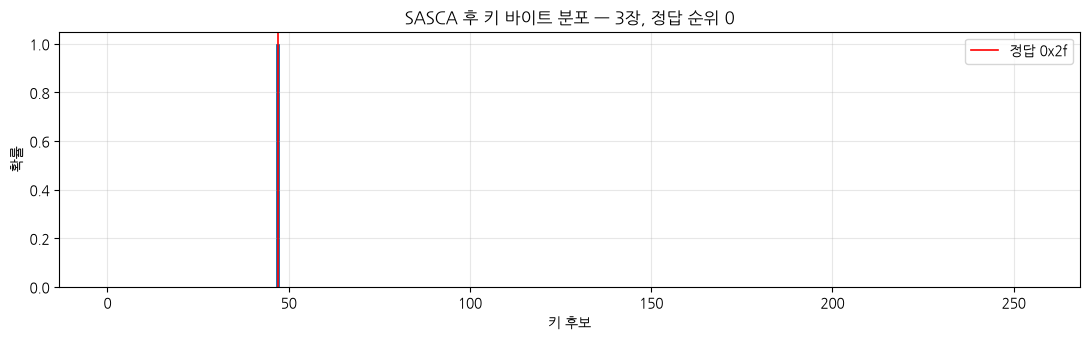

확률 상위 5개 키 후보:
  0x2f  0.999998 ← 정답
  0x2e  0.000002 
  0x5d  0.000000 
  0x30  0.000000 
  0x05  0.000000 


In [7]:
M_PLOT = 3
b = BPState(fg, M_PLOT, {"p": atk["p"][:M_PLOT, BYTE].astype(np.uint32)})
b.set_evidence("y", proba_y[:M_PLOT])
b.bp_loopy(it=3, initialize_states=True)
kd = b.get_distribution("k")

plt.figure(figsize=(11, 3.5))
plt.bar(range(256), kd, width=1.0)
plt.axvline(TRUE_KEY[BYTE], color="r", lw=1.2, label="정답 0x%02x" % TRUE_KEY[BYTE])
plt.xlabel("키 후보"); plt.ylabel("확률")
plt.title("SASCA 후 키 바이트 분포 — %d장, 정답 순위 %d"
          % (M_PLOT, int((kd > kd[TRUE_KEY[BYTE]]).sum())))
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("확률 상위 5개 키 후보:")
for i in np.argsort(kd)[::-1][:5]:
    print("  0x%02x  %.6f %s" % (i, kd[i], "← 정답" if i == TRUE_KEY[BYTE] else ""))

---
## 4. 요약

| 항목 | 내용 |
|------|------|
| 목적 | 여러 중간값의 정보를 **관계식을 따라 합쳐** 키를 좁힌다 |
| 그래프 | 텍스트로 기술. `VAR SINGLE`(키) · `VAR MULTI`(실행별 미지값) · `PUB MULTI`(공개값) |
| API | `FactorGraph(desc, tables)` → `BPState(fg, n, pub)` → `set_evidence(var, proba)` → `bp_loopy(it)` → `get_distribution(var)` |
| 증거 | 프로파일링 모델의 `predict_proba` 출력 `(n, nc)` |
| 반복 수 | 그래프 깊이가 정한다. 증거에서 키까지 두 홉이면 `it≥2` (그 전에는 `get_distribution` 이 `None`) |
| 주의 | **`set_distribution` 은 deprecated**. `set_evidence` 를 쓴다 |

### 이 노트북에서 확인한 것

1. `y` 증거만으로 **파형 한 장**에 키 바이트가 1등이 된다 (비보호 구현).
2. `it=1` 은 `None` — 오류가 아니라 메시지가 아직 키에 닿지 않은 것이다.
3. **`x` 증거를 더해도 아무 이득이 없다.** S-box 가 전단사라 `x` 와 `y` 는 같은 정보다.
   SASCA 의 이득은 **전단사로 이어지지 않는 독립 누설원**(마스킹 공유값, 다른 라운드,
   키 스케줄)이 있을 때 나온다.

### 실패 시 점검

1. `PROPERTY` 의 변수 이름이 선언과 다르면 그래프 생성에서 오류가 난다.
2. `BPState` 의 `n` 과 증거 배열의 행 수가 같아야 한다.
3. `get_distribution` 이 `None` → `it` 을 늘린다.
4. 그래프에 순환이 있으면(`is_cyclic()`) 수렴할 때까지 반복을 늘려야 한다.

다음: `6.0.KeyRank.ipynb` — 바이트별 점수로 128비트 키 전체의 순위를 매긴다.